In [1]:
set.seed(405)
options(stringsAsFactors = FALSE)

In [2]:
required_packages <- c("rstan", "dplyr", "readr", "tibble", "bayesplot", "ggplot2")
missing_packages <- required_packages[!vapply(required_packages, requireNamespace, logical(1), quietly = TRUE)]
if (length(missing_packages) > 0) install.packages(missing_packages, repos = "https://cloud.r-project.org")
invisible(lapply(required_packages, library, character.only = TRUE))
rstan_options(auto_write = TRUE)
options(mc.cores = parallel::detectCores())

Loading required package: StanHeaders


rstan version 2.32.7 (Stan version 2.32.2)


For execution on a local, multicore CPU with excess RAM we recommend calling
options(mc.cores = parallel::detectCores()).
To avoid recompilation of unchanged Stan programs, we recommend calling
rstan_options(auto_write = TRUE)
For within-chain threading using `reduce_sum()` or `map_rect()` Stan functions,
change `threads_per_chain` option:
rstan_options(threads_per_chain = 1)


Warning message:
“package ‘dplyr’ was built under R version 4.4.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘readr’ was built under R version 4.4.3”
Warning message:
“package ‘tibble’ was built under R version 4.4.3”
Warning message:
“package ‘bayesplot’ was built under R version 4.4.3”
This is bayesplot version 1.15.0

- Online documentation and

In [3]:
model_tbl <- readr::read_csv("../output/derived/gss_2024_model_table.csv", show_col_types = FALSE) %>%
  dplyr::mutate(
    degree = as.factor(degree),
    sex = as.factor(sex),
    region = as.factor(region)
  )

In [4]:
model_tbl_fit <- model_tbl %>%
  dplyr::filter(
    !is.na(confinan_ord), !is.na(polviews), !is.na(age_std), !is.na(income_std),
    !is.na(degree), !is.na(sex), !is.na(region)
  )

x_formula <- stats::as.formula(~ polviews + age_std + income_std + degree + sex + region)
X <- stats::model.matrix(x_formula, data = model_tbl_fit)
X <- X[, colnames(X) != "(Intercept)", drop = FALSE]
y <- as.integer(model_tbl_fit$confinan_ord)

stan_data <- list(
  N = nrow(X),
  K = ncol(X),
  y = y,
  X = X
)
tibble::tibble(metric = c("N", "K"), value = c(stan_data$N, stan_data$K))

metric,value
<chr>,<int>
N,2223
K,11


In [5]:
if (exists("fit_m1_nuts")) rm(fit_m1_nuts)
gc()

sm_m1 <- rstan::stan_model(file = "../stan/model1_pooled_ordinal.stan", model_name = "model1_pooled_ordinal")
fit_m1_nuts <- rstan::sampling(
  object = sm_m1,
  data = stan_data,
  chains = 4,
  iter = 2000,
  warmup = 1000,
  seed = 405,
  refresh = 100,
  control = list(adapt_delta = 0.9)
 )

lp_draws <- rstan::extract(fit_m1_nuts, pars = "lp__", permuted = TRUE)$lp__
length(lp_draws)

,used,(Mb),gc trigger,(Mb),limit (Mb),max used,(Mb)
Ncells,1549633,82.8,2431384,129.9,NA,2431384,129.9
Vcells,2790978,21.3,8388608,64.0,16384,5155059,39.4


[1] 4000

In [6]:
fit_summary_raw <- as.data.frame(rstan::summary(fit_m1_nuts)$summary, check.names = FALSE)

fit_summary_raw$parameter <- rownames(fit_summary_raw)
fit_summary <- fit_summary_raw %>% dplyr::relocate(parameter)

summary_cols_preferred <- c("mean", "sd", "2.5%", "50%", "97.5%", "n_eff", "Rhat")
summary_cols_fallback <- c("Mean", "SD", "2.5%", "50%", "97.5%", "Bulk_ESS", "Rhat")

summary_cols_to_show <- if (all(summary_cols_preferred %in% colnames(fit_summary))) {
  summary_cols_preferred
} else {
  summary_cols_fallback[summary_cols_fallback %in% colnames(fit_summary)]
}

fit_summary %>%
  dplyr::select(dplyr::all_of(c("parameter", summary_cols_to_show))) %>%
  head(20)

,parameter,mean,sd,2.5%,50%,97.5%,n_eff,Rhat
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
beta[1],beta[1],-0.030703029,0.02789050,-0.08662114,-0.03021712,0.02250428,3415.894,1.0006506
beta[2],beta[2],-0.265670757,0.04223476,-0.34732861,-0.26601217,-0.18174252,4026.559,1.0003345
beta[3],beta[3],0.022006296,0.04465765,-0.06540147,0.02113511,0.11085246,4245.216,0.9991436
beta[4],beta[4],0.163978261,0.16106285,-0.15412164,0.16384186,0.48450772,1668.215,1.0008938
beta[5],beta[5],0.324831731,0.19773124,-0.06705168,0.32841231,0.70252165,2006.346,1.0012864
beta[6],beta[6],0.006894736,0.17375999,-0.33191902,0.00483400,0.34296399,1750.823,1.0004595
beta[7],beta[7],-0.204388327,0.18661634,-0.57074499,-0.20183507,0.16259647,1836.204,1.0010582
beta[8],beta[8],-0.232568705,0.08238621,-0.39407911,-0.23294080,-0.07148706,3691.246,0.9996917
beta[9],beta[9],0.222239962,0.13399360,-0.04291765,0.22175906,0.49046532,2685.519,1.0002218


In [7]:
colnames(fit_summary)

[1] "parameter" "mean"      "se_mean"   "sd"        "2.5%"      "25%"      
 [7] "50%"       "75%"       "97.5%"     "n_eff"     "Rhat"

In [8]:
ess_col <- if ("n_eff" %in% colnames(fit_summary)) "n_eff" else if ("Bulk_ESS" %in% colnames(fit_summary)) "Bulk_ESS" else NA_character_
rhat_col <- if ("Rhat" %in% colnames(fit_summary)) "Rhat" else NA_character_

diag_summary <- tibble::tibble(
  metric = c("max_rhat", "min_ess", "n_params_rhat_gt_1.01"),
  value = c(
    if (!is.na(rhat_col)) max(fit_summary[[rhat_col]], na.rm = TRUE) else NA_real_,
    if (!is.na(ess_col)) min(fit_summary[[ess_col]], na.rm = TRUE) else NA_real_,
    if (!is.na(rhat_col)) sum(fit_summary[[rhat_col]] > 1.01, na.rm = TRUE) else NA_real_
  )
)
diag_summary

metric,value
<chr>,<dbl>
max_rhat,1.002933
min_ess,1394.429738
n_params_rhat_gt_1.01,0.000000


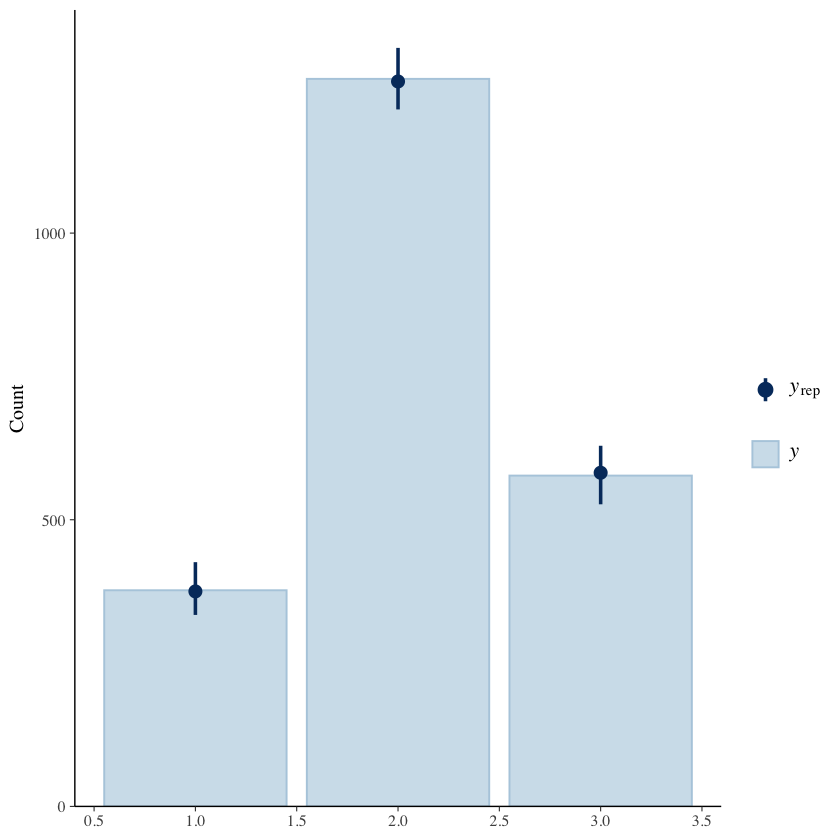

In [9]:
yrep_draws <- rstan::extract(fit_m1_nuts, pars = "y_rep", permuted = TRUE)$y_rep
yrep_subset <- yrep_draws[sample.int(nrow(yrep_draws), size = min(200, nrow(yrep_draws))), , drop = FALSE]
ppc_plot <- bayesplot::ppc_bars(y = y, yrep = yrep_subset)
ppc_plot

In [10]:
dir.create("../output/model1_nuts", recursive = TRUE, showWarnings = FALSE)
saveRDS(fit_m1_nuts, file = "../output/model1_nuts/fit_m1_nuts.rds")
readr::write_csv(fit_summary, "../output/model1_nuts/fit_summary.csv")
readr::write_csv(diag_summary, "../output/model1_nuts/diagnostics_summary.csv")
ggplot2::ggsave(filename = "../output/model1_nuts/ppc_bars_model1.png", plot = ppc_plot, width = 7, height = 4, dpi = 150)